# 2. The redox tower, and how conditions change the energy

Standard-state values say what is *possible*. This notebook is about the gap
between that and what actually pays in a real environment.

In [1]:
import warnings

import matplotlib.pyplot as plt

import microbial_thermo as mt

warnings.filterwarnings("ignore", category=UserWarning)

conditions = mt.Conditions(temperature_c=25.0, pH=7.0)

## The reference couples

Potentials are computed at the pH and temperature asked for, so this table is
not a pH 7 snapshot — change the conditions and the numbers move.

In [2]:
from microbial_thermo.tower import tower_table

tower_table(conditions)

,couple,E0' (V),n electrons,group
0,SO4-2/SO3-2,-0.521290,2.0,sulfur
1,2H+/H2,-0.414115,2.0,hydrogen
2,CO2/acetate,-0.269422,8.0,carbon
3,S0/HS-,-0.269068,2.0,sulfur
4,CO2/CH4,-0.254980,8.0,carbon
5,SO4-2/HS-,-0.216764,8.0,sulfur
6,NO2-/NH4+,0.348837,6.0,nitrogen
7,NO3-/NH4+,0.363428,8.0,nitrogen
8,NO3-/NO2-,0.407201,2.0,nitrogen
9,NO3-/N2,0.729229,10.0,nitrogen


Compare against pH 5 to see the proton-coupled couples shift while
Fe(III)/Fe(II) stays put:

In [3]:
tower_table(mt.Conditions(temperature_c=25.0, pH=5.0))

,couple,E0' (V),n electrons,group
0,SO4-2/SO3-2,-0.402971,2.0,sulfur
1,2H+/H2,-0.295797,2.0,hydrogen
2,S0/HS-,-0.209909,2.0,sulfur
3,CO2/acetate,-0.165893,8.0,carbon
4,CO2/CH4,-0.136661,8.0,carbon
5,SO4-2/HS-,-0.083655,8.0,sulfur
6,NO2-/NH4+,0.506595,6.0,nitrogen
7,NO3-/NH4+,0.511326,8.0,nitrogen
8,NO3-/NO2-,0.525519,2.0,nitrogen
9,Fe3+/Fe2+,0.769713,1.0,metal


## Drawing the tower

The tower is normalised to an electron pair. That is what makes the energy
scale bar exact: with *n* fixed, $\Delta G = -nF\Delta E$, so a *difference*
in potential converts to kJ/mol by the constant $2F$ = 192.97 kJ mol⁻¹ V⁻¹.

Read a reaction's yield straight off the figure by comparing the length of
the donor-to-acceptor arrow against the scale bar.

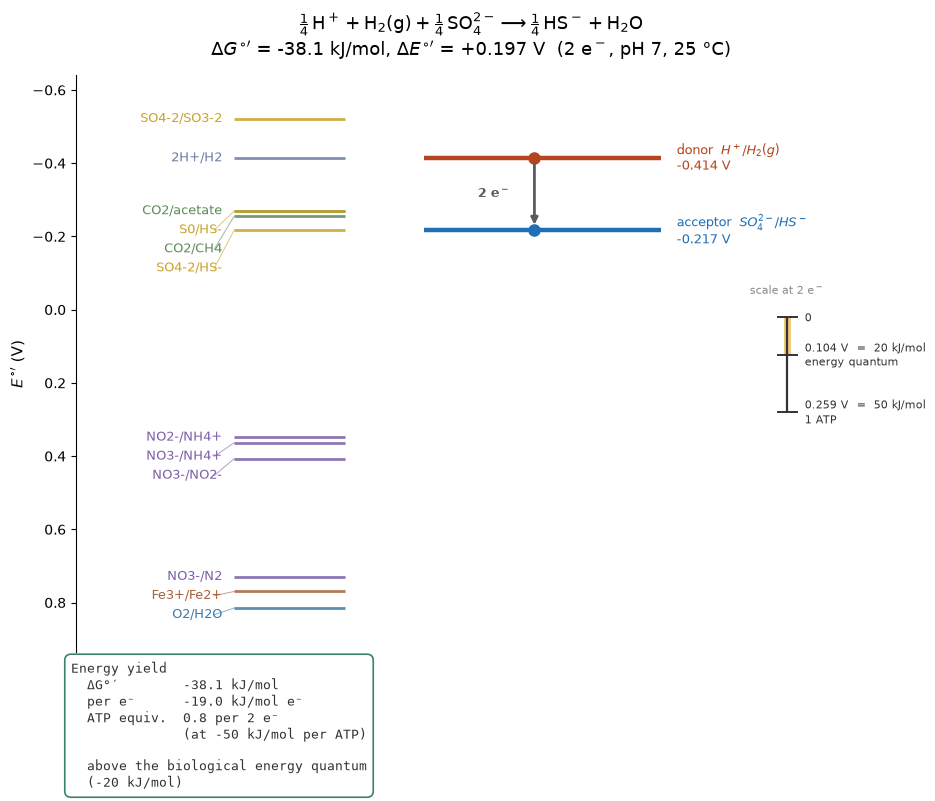

In [4]:
from microbial_thermo.figures import plot_redox_tower

reaction = mt.Reaction.from_couples(
    donor=("H2(g)", "H+"), acceptor=("HS-", "SO4-2"), conditions=conditions
)
plot_redox_tower(reaction)
plt.show()

Note the scale bar is a *bar*, not an axis. An absolute kJ/mol axis would
imply each couple has an absolute free energy; only differences between
couples carry energy.

### The tower is not a fixed table

Printed towers invite the reading that these potentials are constants. They
are not, and the couples do not move together. Three things shift them:

* **pH**, through the protons in the half reaction — $-59.16 \times (\text{H}^+/n)$ mV
  per pH unit at 25 °C. Fe(III)/Fe(II) has no protons and does not move at all.
* **temperature**, through every formation energy.
* **the oxidised:reduced activity ratio**, by $(RT/nF)\ln(\text{ratio})$ — so a
  one-electron couple swings eight times as far as an eight-electron one.

Build the grid once, then move the sliders. Nothing calls the backend while
a slider moves; pH and temperature are looked up and the ratio is applied in
closed form.

In [ ]:
from microbial_thermo.tower import tower_grid

grid = tower_grid(
    ph_values=(5.0, 6.0, 7.0, 8.0, 9.0),
    temperature_values=(4.0, 25.0, 55.0),
)
print(f"{len(grid.labels)} couples over {len(grid.ph_values)} pH x "
      f"{len(grid.temperature_values)} temperatures")

In [ ]:
from microbial_thermo.figures import interactive_tower

interactive_tower(grid)

The crossing worth hunting for: at pH 7 and 25 °C oxygen sits above iron.
Raise the ferric:ferrous ratio past about $10^{1.5}$ and iron overtakes it,
because a one-electron couple moves twice as fast per decade as the
two-electron oxygen couple.

In [ ]:
for log_ratio in (0, 1, 2):
    order = [row[0] for row in grid.entries_at(7.0, 25.0, 10.0**log_ratio)]
    print(f"ratio 10^{log_ratio}: strongest oxidant is {order[-1]}")

The same grid exports to a standalone HTML file. The sliders are rebuilt in
JavaScript there and the Nernst shift is redone in the page, so it keeps
working with no kernel behind it — hand it to a student as a single file.

In [ ]:
from microbial_thermo.figures import plot_interactive_tower

plot_interactive_tower(grid, save_html="tower_interactive")
print("wrote tower_interactive.html")

## Standard state is a fiction

$\Delta G^{\circ\prime}$ puts hydrogen at 1 bar. Real hydrogen in a sediment
is nanomolar. Sweeping it shows where methanogenesis stops paying.

In [5]:
from microbial_thermo.sweep import partial_pressure_axis, sweep

realistic = mt.Conditions(
    temperature_c=25.0, pH=7.0, activity_model="ideal",
    partial_pressures={"H2(g)": 1e-4},
)
methanogenesis = mt.Reaction.from_couples(
    donor=("H2(g)", "H+"), acceptor=("methane", "CO2(aq)"), conditions=realistic
)

result = sweep(methanogenesis, partial_pressure_axis("H2(g)"))
frame = result.to_frame()
frame.iloc[::4]

,pH2(g) (bar),dG (kJ/mol),dG per e- (kJ/mol)
0,1.000000e-10,26.371627,13.185814
4,4.641589e-09,16.858278,8.429139
8,2.154435e-07,7.344929,3.672464
12,1.000000e-05,-2.168420,-1.084210
16,4.641589e-04,-11.681770,-5.840885
20,2.154435e-02,-21.195119,-10.597559
24,1.000000e+00,-30.708468,-15.354234


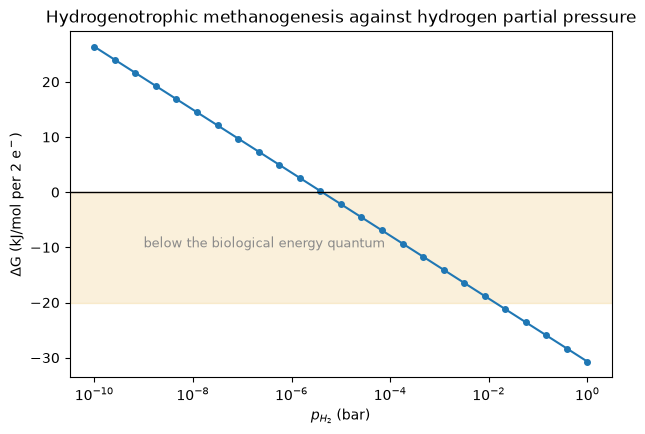

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(result.axis.values, result.delta_g, marker="o", markersize=4)
ax.axhline(0, color="black", linewidth=1)
ax.axhspan(-20, 0, color="#E8B84B", alpha=0.2)
ax.set_xlabel("$p_{H_2}$ (bar)")
ax.set_ylabel("ΔG (kJ/mol per 2 e$^-$)")
ax.set_title("Hydrogenotrophic methanogenesis against hydrogen partial pressure")
ax.annotate(
    "below the biological energy quantum",
    xy=(1e-9, -10), fontsize=9, color="#8A8A8A",
)
plt.show()

The curve crosses zero near $10^{-5}$ bar. That threshold is why
methanogens and their syntrophic partners have to keep hydrogen so low, and
why the two cannot both be comfortable at once.

### The syntrophic window

That last claim is worth drawing rather than asserting. A propionate
oxidiser *releases* hydrogen and is poisoned by it; its methanogenic partner
*consumes* hydrogen and needs enough to work with. Put both on one axis and
the overlap where each is exergonic is the only place the partnership can
live.

In [ ]:
from microbial_thermo.figures import plot_syntrophy_window
from microbial_thermo.library import reaction

sediment = mt.Conditions(
    temperature_c=25.0,
    pH=7.0,
    activity_model="ideal",
    partial_pressures={"H2(g)": 1e-5},
    concentrations={
        "Propanoate(aq)": 1e-4,
        "Acetate": 1e-4,
        "HCO3-": 2e-3,
        "CO2(aq)": 1e-3,
        "Methane(aq)": 1e-4,
    },
)

producer = reaction("syntrophic_propionate_oxidation", sediment)
consumer = reaction("hydrogenotrophic_methanogenesis", sediment)

figure, window = plot_syntrophy_window(
    producer,
    consumer,
    producer_label="propionate oxidation (Syntrophobacter)",
    consumer_label="hydrogenotrophic methanogenesis",
)
plt.show()

In [ ]:
print(f"window: {window.low:.2e} to {window.high:.2e} bar H2")
print(f"width : {window.decades:.2f} decades")
pressure, shared = window.best_shared
print(f"at best, the worse-off partner gets {shared:.1f} kJ/mol (at {pressure:.1e} bar)")

Both partners are normalised to the same electron pair, which is what makes
one shared y axis legitimate; the figure refuses to draw partners that are
not.

The number to sit with is the last one. At the pressure that treats them
most evenly, neither partner is guaranteed even one biological energy
quantum. Syntrophs are not merely thermodynamically tight — they are living
inside the band this library shades to mean "probably not enough".

## Temperature

pyGCC gives real temperature dependence rather than a van 't Hoff
approximation, over 0.01 to 100 °C.

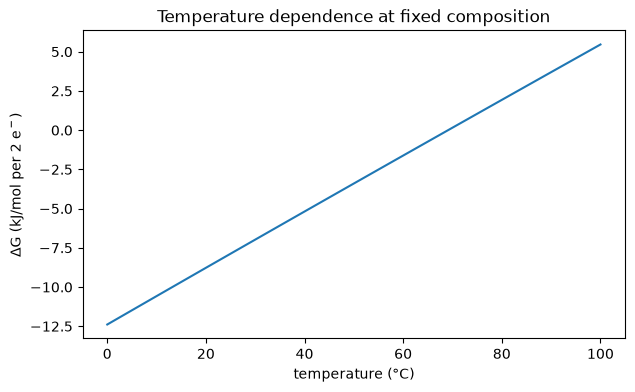

In [7]:
from microbial_thermo.sweep import temperature_axis

warm = sweep(methanogenesis, temperature_axis())
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(warm.axis.values, warm.delta_g)
ax.set_xlabel("temperature (°C)")
ax.set_ylabel("ΔG (kJ/mol per 2 e$^-$)")
ax.set_title("Temperature dependence at fixed composition")
plt.show()

## The interactive explorer

Pick the x-axis variable from the dropdown. Writing it to HTML gives a
self-contained file — dropdown, hover and the SVG download button all work
with no Python behind it, so it can be handed to students directly.

In [8]:
from microbial_thermo.figures import plot_energy_explorer
from microbial_thermo.figures.explorer import SVG_CONFIG

figure = plot_energy_explorer(methanogenesis)
figure.show(config=SVG_CONFIG)

In [9]:
plot_energy_explorer(methanogenesis, save_html="explorer_methanogenesis")
print("wrote explorer_methanogenesis.html")

wrote explorer_methanogenesis.html
